<a href="https://colab.research.google.com/github/chaitragopalappa/MIE590-690D/blob/main/4_PINN/1d_PINN_Epi_increment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROBLEM SETTING (Epidemic Example)
A step-up from the simple SIR model, to include human behavior,
- The functional form of human behavior (such as compliance to epidemic guidelines over time) is unknown.
- Dynamic transmission rate $\beta(t)=f(\beta, x(t))$; where $x$, the system state, includes the epidemic state
 and human behavior.





## State variables
- $x_1(t)$: susceptible population,
- $x_2(t)$: mildly infectious individuals,
- $x_3(t)$: hospitalized or severe infections,
- $x_4(t)\in[0,1]$: public compliance level.

## Inputs
- $\beta_0$: Baseline transmission rate.
- $\beta_e$: Effective transmission rate (accounting for changes in behavior from compliance  $x_4$.
- $U_{ac}(t)$: Healthcare resource allocation rate.
- $T_u$: Intervention response time
- $T_p$: Healthcare system response time.
- $T_f$: Behavioral adaptation time.
- $T_p$ and $T_f$ are assumed proportional to $T_u$.
- $\gamma_h$ is the hospitalization rate.
----


## Ordinary Differential Equations
$$\dot{x}_1 = \beta_e(t)\frac{x_1x_2}{N} +   \frac{x_2}{T_u} + \frac{x_3}{T_p}$$
$$\dot{x}_2= -\gamma_hx_2 - \frac{x_2}{T_u} +\beta_e(t)\frac{x_1x_2}{N}$$

$$\dot{x}_3=-\frac{x_3}{T_p}+\gamma_h x_2$$

$$\dot{x}_4=\frac{f_s(R_p)-x_4}{T_f}$$

where
$$\text{Effective Transmission Rate:} \beta_e(t)= -\beta_0\left(1-\eta x_4(t)\right) \qquad
0\le \eta \le 1$$
$$\text{Perceived Epidemic risk:} R_p(t)=w_1x_2(t)+w_2x_3(t).$$

$$ \text{Behavioral adaptation:} f_s(R_p)=\frac{1}{1+\exp\left[-k\left(R_p-R_c\right)\right]}$$

$$\text{Intervention Time Constants }
T_u(t)=\frac12\min\left(\frac{c}{U_{ac}(t)},100\right)
,\qquad
T_p=T_{p,0}T_u,\qquad
T_f=T_{f,0}T_u
,\qquad
where, \qquad
T_{p,0}=1.5,\qquad
T_{f,0}=6.
$$



# Assume:
- we do not know $\beta_0$ and
- we do not know functional form of $f_s(.)$
- $Tu, Tp, Tf$ are known constants
## OBJECTIVE:
  - Use PINN with additional network to learn unknown function
  - Use PySR for discovering mathematical form of unknown function



## PINN
### NEURAL NETWORK ARCHITECTURE :
- x-net is a newtork to represent $x=f(t)$;
- f_net is a network to represent $f_s=f(t,x)$


In [33]:
!pip install pysr
!pip install torchdiffeq

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from torchdiffeq import odeint
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)

In [35]:
N=1
eta= 0.8
Tu = 20
Tp = 20
Tf = 20
gamma_h=0.05
Rc = 0.5 # (0 to 1; is the risk threshold at which the population begins substantially changing behavior.
k = 2 #controls how rapidly behavior changes around that threshold; 8 is moderate. 1 is rapidly etc.

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Setup X-Net training. Input layer is 't' output layer are the states ('x'). NUmber in outlayer should match with number of state variables

In [36]:
# ── X-Net: maps t → [x1, x2, x3, x4] ────────────────────────────────────────
class XNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 4),
        )

    def forward(self, t):
        return self.net(t)

f_net takes 'x'(states) and 't' (time) in input layer and outputs $\dot{x}$ of the unknown function

In [37]:
# ── F-Net: maps [t, x1, x2, x3, x4] → scalar fs  (behavioral response) ───────
class FNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, t, x):
        inp = torch.cat([t, x], dim=1)
        return self.net(inp)

Put it together in PINN. Add the uknown coefficients to the output using the parameter layer, so it can part of the parameters to train.

In [38]:
# ── Full PINN ─────────────────────────────────────────────────────────────────
class EpiNet(nn.Module):
    def __init__(self, beta0_init: float = 0.1):
        super().__init__()
        self.x_net = XNet()
        self.f_net = FNet()
        # Learnable scalar β₀
        self.beta0 = nn.Parameter(torch.tensor([beta0_init], dtype=torch.float32))

    def forward(self, t):
        x = self.x_net(t)
        f = self.f_net(t, x)
        return x, f

# Generate true data (or upload true data)

In [39]:
# ── ODE simulation (ground truth) ────────────────────────────────────────────
def simulate_ODEs(x_init, t_span, obs_num):
    def odes(t, x):
        x1, x2, x3, x4 = x
        beta0 = 0.3
        Rp = 0.2 * x2 + 0.8 * x3 # Perceived epidemic risk
        fs = 1.0 / (1.0 + np.exp(-k * (Rp - Rc)))# Behavioral response function
        dx1dt = -beta0 * (1 - eta * x4) * x1 * x2 / N + x2 / Tu + x3 / Tp
        dx2dt = -gamma_h * x2 - x2 / Tu + beta0 * (1 - eta * x4) * x1 * x2 / N
        dx3dt = -x3 / Tp + gamma_h * x2
        dx4dt = (fs - x4) / Tf
        return [dx1dt, dx2dt, dx3dt, dx4dt]

    # Solve ODEs using RK45 (for u_obs)
    t_eval = np.linspace(t_span[0], t_span[1], obs_num)
    sol = solve_ivp(odes, t_span, x_init, method="RK45", t_eval=t_eval)
    return np.column_stack((sol.t, sol.y[0], sol.y[1], sol.y[2], sol.y[3]))#note solve_ivp default is y, so use sol.y here


In [40]:
# Set up simulation
initial_state = [0.95, 0.05, 0.0, 0.0]
t_span = [0, 100]
obs_num = 1000

#Solve ODES
x_obs = simulate_ODEs(initial_state, t_span, obs_num)

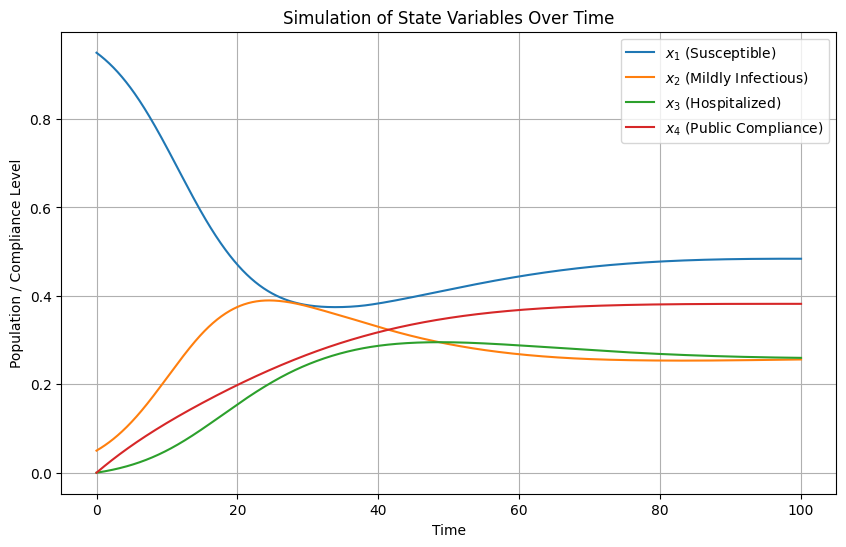

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(x_obs[:, 0], x_obs[:, 1], label='$x_1$ (Susceptible)')
plt.plot(x_obs[:, 0], x_obs[:, 2], label='$x_2$ (Mildly Infectious)')
plt.plot(x_obs[:, 0], x_obs[:, 3], label='$x_3$ (Hospitalized)')
plt.plot(x_obs[:, 0], x_obs[:, 4], label='$x_4$ (Public Compliance)')
plt.xlabel('Time')
plt.ylabel('Population / Compliance Level')
plt.title('Simulation of State Variables Over Time')
plt.legend()
plt.grid(True)
plt.show()

### Data batching

In [42]:
# Collocation points for ODE loss
N_collocation = 10000
ODE_batch_size = 1000
X_train_ODE = torch.linspace(t_span[0], t_span[1], N_collocation, device=DEVICE).unsqueeze(1)
ode_dataset = TensorDataset(X_train_ODE)
ode_loader = DataLoader(ode_dataset, batch_size=ODE_batch_size, shuffle=True)

# Observed data for data loss
data_batch_size = 10
X_train_data = torch.tensor(x_obs[:, :1], dtype=torch.float32, device=DEVICE)
y_train_data = torch.tensor(x_obs[:, 1:], dtype=torch.float32, device=DEVICE)
data_dataset = TensorDataset(X_train_data, y_train_data)
data_loader = DataLoader(data_dataset, batch_size=data_batch_size, shuffle=True)

## PINN TRAINING

In [43]:
epi_pinn = EpiNet()
optimizer = optim.Adam(epi_pinn.parameters(), lr=0.001)

# Convert initial_state to a PyTorch tensor
initial_state = torch.tensor(initial_state, dtype=torch.float32)

In [44]:
epochs = 1500
for epoch in range(epochs):
    for (t_ODE,), (t, x) in zip(ode_loader, data_loader):
        optimizer.zero_grad()

        # -------------------------------------------------------------------------
        # 1. DATA LOSS (Comparing sparse model predictions against actual measurements)
        # -------------------------------------------------------------------------
        pred_x,_  = epi_pinn(t)
        loss_data = torch.mean((pred_x - x) ** 2)

        # -------------------------------------------------------------------------
        # 2. PHYSICS LOSS (Using a denser grid of collocation points to enforce laws)
        # -------------------------------------------------------------------------
        t_ODE.requires_grad_(True) # This line was added
        pred_phys, pred_unknown_f= epi_pinn(t_ODE)
        x1, x2, x3, x4 = pred_phys[:, 0:1], pred_phys[:, 1:2], pred_phys[:, 2:3], pred_phys[:, 3:4]

        # Compute derivatives from predicted values via autograd;torch.ones_like(x1) keeps it to element-wise derivatives (the default in torch autograd is Vector-Jacobian Products)
        dx1dt = torch.autograd.grad(x1, t_ODE, torch.ones_like(x1), create_graph=True)[0]
        dx2dt = torch.autograd.grad(x2, t_ODE, torch.ones_like(x2), create_graph=True)[0]
        dx3dt = torch.autograd.grad(x3, t_ODE, torch.ones_like(x3), create_graph=True)[0]
        dx4dt = torch.autograd.grad(x4, t_ODE, torch.ones_like(x4), create_graph=True)[0]

        # Physics residuals
        beta0 = epi_pinn.beta0 #get from learned NN
        fs = pred_unknown_f #get from learned NN# Behavioral response function
        f_x1 = dx1dt - (-beta0 * (1 - eta * x4) * x1 * x2 / N + x2 / Tu + x3 / Tp)
        f_x2 = dx2dt - ( -gamma_h * x2 - x2 / Tu + beta0 * (1 - eta * x4) * x1 * x2 / N)
        f_x3 = dx3dt - ( -x3 / Tp + gamma_h * x2)
        f_x4 = dx4dt - ((fs - x4) / Tf)
        loss_physics = torch.mean(f_x1**2) + torch.mean(f_x2**2) + torch.mean(f_x3**2)+ torch.mean(f_x4**2)

        # -------------------------------------------------------------------------
        # 3. INITIAL CONDITION LOSS
        # -------------------------------------------------------------------------
        t_zero = torch.tensor([[0.0]])
        pred_zero, _ = epi_pinn(t_zero)
        loss_initial = torch.mean((pred_zero - initial_state)**2)

        # -------------------------------------------------------------------------
        # TOTAL LOSS: Balances observations + structural physics constraints
        # -------------------------------------------------------------------------
        total_loss = 1 * loss_data + 2.0 * loss_physics + 1 * loss_initial

        total_loss.backward()
        optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Data Loss: {loss_data.item():.6f} | Physics Loss: {loss_physics.item():.6f}")

epi_pinn.eval()
with torch.no_grad():
        t_val = torch.linspace(t_span[0], t_span[1], 1000).unsqueeze(1)
        pred_x_PINN, _ = epi_pinn(t_val)

print(f"\nFinal learned β₀: {epi_pinn.beta0.item():.4f}  (true value: 0.3)")

Epoch 0 | Data Loss: 0.012557 | Physics Loss: 0.001522
Epoch 500 | Data Loss: 0.000008 | Physics Loss: 0.000001
Epoch 1000 | Data Loss: 0.000001 | Physics Loss: 0.000000

Final learned β₀: 0.2997  (true value: 0.3)


## VIZUALIZE OUTPUTS

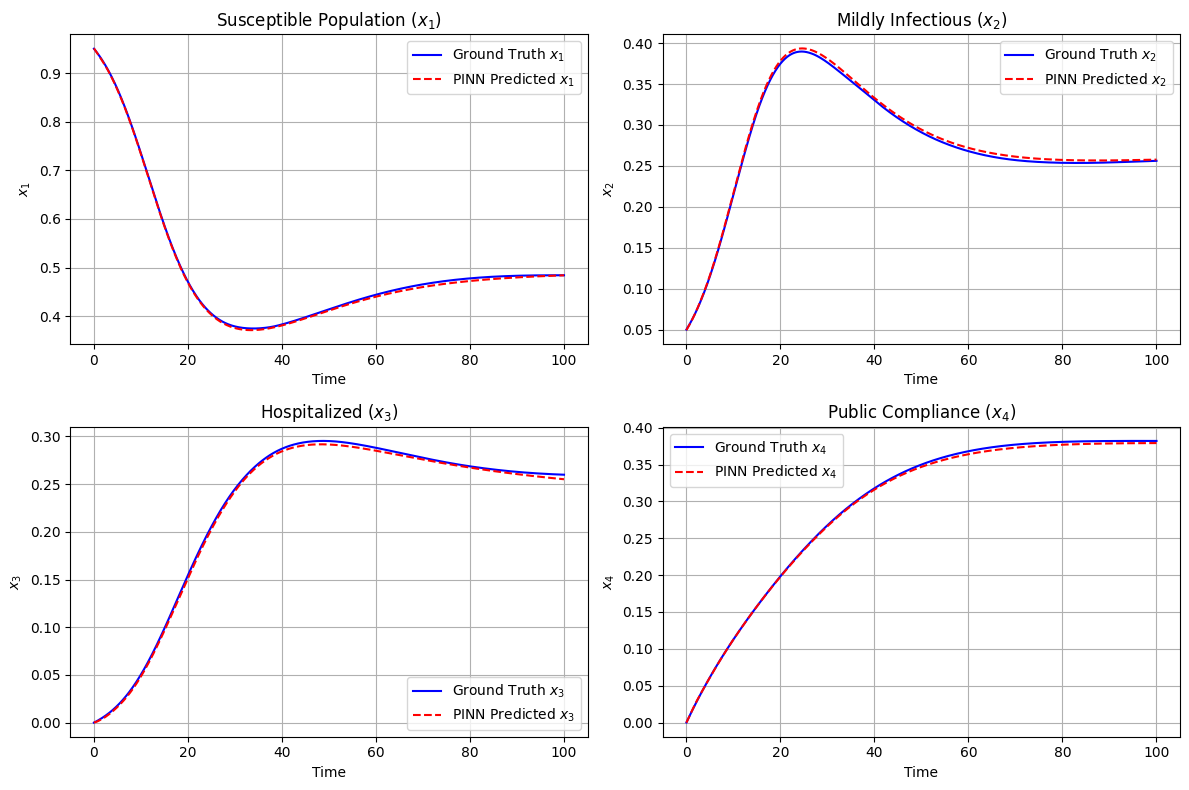

In [45]:
# ── Plot 2: PINN state predictions vs ground truth ───────────────────────────
# Replaces PINN.predict() — just a no-grad forward pass
epi_pinn.eval()
with torch.no_grad():
    X_test_nograd = torch.linspace(t_span[0], t_span[1], 1000, device=DEVICE).unsqueeze(1)
    u_pred, _ = epi_pinn(X_test_nograd)

u_pred_np = u_pred.numpy()  # (1000, 4)
t_pred_np = X_test_nograd.numpy()

state_info = [
    (1, "x_1", "Susceptible Population ($x_1$)"),
    (2, "x_2", "Mildly Infectious ($x_2$)"),
    (3, "x_3", "Hospitalized ($x_3$)"),
    (4, "x_4", "Public Compliance ($x_4$)"),
]

plt.figure(figsize=(12, 8))
for i, (obs_col, label, title) in enumerate(state_info, start=1):
    plt.subplot(2, 2, i)
    plt.plot(x_obs[:, 0],   x_obs[:, obs_col],    "b-",  label=f"Ground Truth ${label}$")
    plt.plot(t_pred_np,     u_pred_np[:, i - 1],  "r--", label=f"PINN Predicted ${label}$")
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel(f"${label}$")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


# DISCOVER equations using PySR

In [46]:
!pip install pysr

In [47]:
import sympy
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pysr import PySRRegressor
from sklearn.model_selection import train_test_split

/usr/local/lib/python3.12/dist-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/pysr/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliacall/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] WARNING: You have Julia 1.12.6 installed but 1.10.3 - 1.11 is required.
[juliapkg]   It is recommended that you upgrade Julia or install JuliaUp.
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.11.9 to /root/.julia/environments/pyjuliapkg/pyjuliapkg/install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[juliapkg]   have Julia installed in multiple locations. It is recommended to
[juliapkg]   install JuliaUp (https://github.com/JuliaLang/juliaup) or Julia
[juliapkg]   (https://julialang.org/downloads) yourself.
[juliapkg] Downloading Julia

In [49]:
epi_pinn.eval()
with torch.no_grad():
        t_val = torch.linspace(t_span[0], t_span[1], 1000).reshape(-1, 1)
        pred_y_PINN, f = epi_pinn(t_val)
#print(t_val.numpy())
df = pd.DataFrame({
    't': t_val.numpy().flatten(),
    'x1': pred_y_PINN[:, 0].numpy(),
    'x2': pred_y_PINN[:, 1].numpy(),
    'x3': pred_y_PINN[:, 2].numpy(),
    'x4': pred_y_PINN[:, 3].numpy(),
    'f': f.numpy().flatten(),
})

X = df.iloc[:, :5].to_numpy()
y = df.loc[:, 'f'].to_numpy()
print(df.iloc[:, :6].head)

<bound method NDFrame.head of               t        x1        x2        x3        x4         f
0      0.000000  0.950597  0.049321  0.000056 -0.000172  0.269143
1      0.100100  0.949446  0.050329  0.000259  0.001217  0.271803
2      0.200200  0.948004  0.051322  0.000407  0.002562  0.274192
3      0.300300  0.946482  0.052293  0.000538  0.003926  0.276343
4      0.400400  0.944988  0.053257  0.000677  0.005327  0.278268
..          ...       ...       ...       ...       ...       ...
995   99.599602  0.483795  0.257602  0.255255  0.379083  0.382028
996   99.699699  0.483828  0.257616  0.255207  0.379085  0.382016
997   99.799797  0.483862  0.257630  0.255159  0.379087  0.382004
998   99.899902  0.483895  0.257644  0.255112  0.379088  0.381992
999  100.000000  0.483927  0.257658  0.255064  0.379090  0.381980

[1000 rows x 6 columns]>


In [50]:
default_pysr_params = dict(
    populations=30,
    model_selection="score",
    #loss="L1DistLoss()",
    elementwise_loss="loss(prediction, target) = (prediction - target)^2"
)

In [51]:
# Learn equations

# Learn equations
model = PySRRegressor(
    niterations=30,
    #binary_operators=["+", "*"],
    #unary_operators=["cos", "exp", "sin"],
    **default_pysr_params,
)

model.fit(X, y)

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 1.560e+04
Progress: 131 / 900 total iterations (14.556%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.076e-03  0.000e+00  y = 0.37311
5           2.017e-05  9.943e-01  y = (x₂ * x₄) - -0.28837
7           1.347e-05  2.020e-01  y = ((x₄ * x₂) * 1.0863) - -0.28106
13          1.886e-06  3.276e-01  y = ((x₁ * -0.078189) + (x₃ - -1.1182)) + (-0.76368 - (x₃ ...
                                      * 0.74445))
27          1.708e-06  7.068e-03  y = (0.28866 - ((x₁ - (((x₃ / (x₁ * (x₃ + (1.3453 * (0.574...
                                      49 - x₂))))) - -0.82539) * x₄)) * (0.077174 * (x₄ / x₄))))...
                                       / 0.77692
──────────────────────────────────────────────────────────────────────────────────────────────────

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.076e-03  0.000e+00  y = 0.37311
5           2.017e-05  9.943e-01  y = (x₂ * x₄) - -0.28837
7           1.290e-05  2.235e-01  y = (x₄ * (x₂ + 0.025484)) + 0.2809
9           1.886e-06  9.613e-01  y = (0.35454 - (x₁ * 0.078185)) + (x₃ * 0.25556)
11          1.865e-06  5.555e-03  y = (((x₂ * 0.07747) - -1.4056) - (x₃ * -0.33446)) + -1.12...
                                      9
13          1.865e-06  1.699e-06  y = (x₃ + (((x₂ * 0.077482) - -1.0292) - (x₃ * 0.66555))) ...
                                      + -0.75267
15          1.181e-06  2.283e-01  y = (x₃ + ((x₂ * 0.059365) + 0.27951)) - (((x₂ * -0.13921)...
                                       + 0.69729) * x₃)
17          1.169e-06  5.291e-03  y = (x₃ + (((x₂ * 0.059048) - -1.034) - (x₃ * ((x₂ * -0.13...
                                      746) + 0.69736)))) + -0.75417
23

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                         0.37311435   
	1   >>>>  0.994297                            (x2 * x4) - -0.28836697   
	2         0.223482              (x4 * (x2 + 0.025484093)) + 0.2808952   
	3         0.961331  (0.3545366 - (x1 * 0.078185014)) + (x3 * 0.255...   
	4         0.005555  (((x2 * 0.07747049) - -1.4055855) - (x3 * -0.3...   
	5         0.000002  (x3 + (((x2 * 0.07748159) - -1.0292461) - (x3 ...   
	6         0.228339  (x3 + ((x2 * 0.05936474) + 0.2795105)) - (((x2...   
	7         0.005291  (x3 + (((x2 * 0.05904824) - -1.0339918) - (x3 ...   
	8         0.017990  (0.3459513 - ((x1 - (((x3 / ((x1 * 0.8014994) ...   
	9         0.002196  x3 + (0.27972326 - ((x2 * -0.059003353) + ((((...   
	10        0.016190  (x3 + 0.27950326) - ((x2 * -0.060458787) + (((...   
	
	        loss  complexity  
	0   0.001076           1  
	1   0.000020           5  
	2   0.000013           7  
	3   0.000002           9  
	4   0.000002          11  
	5   0.000002          13  
	6   0.000001          15  
	7   0.000001          17  
	8   0.000001          23  
	9   0.000001          27  
	10  0.000001          29  
]

  - outputs/20260708_222054_oYZywo/hall_of_fame.csv


## SEE DISCOVERED FUNCTIONAL FORM

In [53]:
#Rp = 0.2 * x2 + 0.8 * x3 # Perceived epidemic risk
#fs = 1.0 / (1.0 + np.exp(-k * (Rp - Rc)))# Behavioral response function

model.sympy()
print("Correct f= 1.0 / (1.0 + np.exp(-k * (0.2 * x2 + 0.8 * x3 -", Rc,")))")
print("Discovered:", model.sympy())

Correct f= 1.0 / (1.0 + np.exp(-k * (0.2 * x2 + 0.8 * x3 - 0.5 )))
Discovered: x2*x4 - 1*(-0.28836697)


# VISUALIZE estimates from discovered functional form, NN blackbox, and actual functional form

In [54]:
Rp = 0.2 * df['x2'] + 0.8 * df['x3']
df['actual f'] = 1.0 / (1.0 + np.exp(-k * (Rp - Rc)))

# Evaluate the discovered equation using the DataFrame columns
# The discovered equation is: x2*x4 - 1*(-0.28836697)
df['discovered f'] = df['x2'] * df['x4'] + 0.28836697

print(df.head())

        t        x1        x2        x3        x4         f  actual f  \
0  0.0000  0.950597  0.049321  0.000056 -0.000172  0.269143  0.272856   
1  0.1001  0.949446  0.050329  0.000259  0.001217  0.271803  0.273000   
2  0.2002  0.948004  0.051322  0.000407  0.002562  0.274192  0.273126   
3  0.3003  0.946482  0.052293  0.000538  0.003926  0.276343  0.273245   
4  0.4004  0.944988  0.053257  0.000677  0.005327  0.278268  0.273365   

   discovered f  
0      0.288359  
1      0.288428  
2      0.288498  
3      0.288572  
4      0.288651  


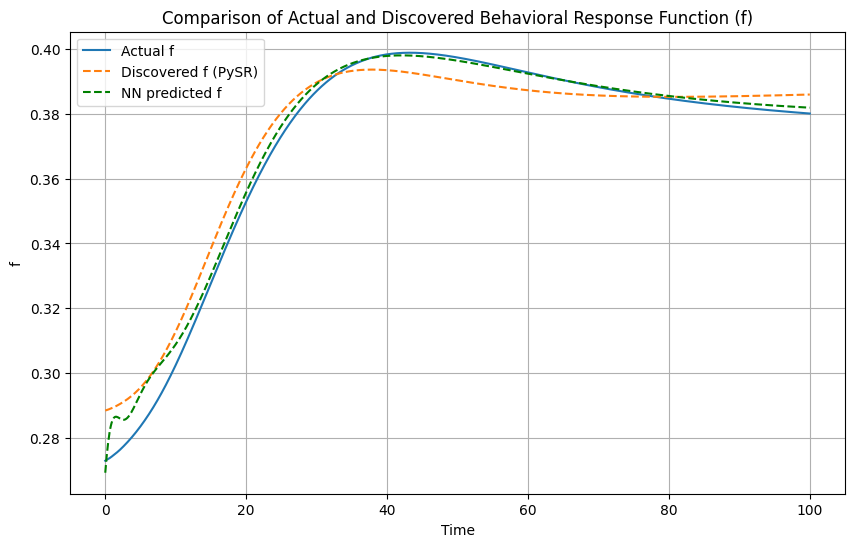

In [57]:
plt.figure(figsize=(10, 6))
plt.plot(df['t'], df['actual f'], label='Actual f')
plt.plot(df['t'], df['discovered f'], label='Discovered f (PySR)', linestyle='--')
plt.plot(df['t'], df['f'], label='NN predicted f', linestyle='--', color ='g')
plt.xlabel('Time')
plt.ylabel('f')
plt.title('Comparison of Actual and Discovered Behavioral Response Function (f)')
plt.legend()
plt.grid(True)
plt.show()